In [6]:
import pandas as pd
import numpy as np
import seaborn as sns

In [7]:
data = pd.read_csv("student.csv")

In [9]:
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,associate's degree,free/reduced,none,81.0,77.0,80.0
1,male,group C,associate's degree,free/reduced,completed,97.0,100.0,100.0
2,female,group C,bachelor's degree,standard,completed,57.0,61.0,58.0
3,female,group D,some college,free/reduced,none,68.0,64.0,63.0
4,female,group D,master's degree,standard,completed,85.0,95.0,93.0
...,...,...,...,...,...,...,...,...
995,female,group D,associate's degree,standard,none,78.0,72.0,70.0
996,female,group D,associate's degree,free/reduced,none,72.0,81.0,82.0
997,male,group C,some high school,free/reduced,none,70.0,67.0,72.0
998,male,group C,some high school,standard,none,77.0,87.0,88.0


In [10]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,associate's degree,free/reduced,none,81.0,77.0,80.0
1,male,group C,associate's degree,free/reduced,completed,97.0,100.0,100.0
2,female,group C,bachelor's degree,standard,completed,57.0,61.0,58.0
3,female,group D,some college,free/reduced,none,68.0,64.0,63.0
4,female,group D,master's degree,standard,completed,85.0,95.0,93.0


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.describe()

,math score,reading score,writing score
count,995.000000,995.000000,995.000000
mean,71.829146,74.411055,73.714573
std,13.847944,13.607123,13.981050
min,29.000000,26.000000,29.000000
25%,63.000000,65.500000,64.000000
50%,72.000000,75.000000,74.000000
75%,81.000000,84.000000,84.000000
max,100.000000,100.000000,100.000000


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   str    
 1   race/ethnicity               1000 non-null   str    
 2   parental level of education  995 non-null    str    
 3   lunch                        995 non-null    str    
 4   test preparation course      995 non-null    str    
 5   math score                   995 non-null    float64
 6   reading score                995 non-null    float64
 7   writing score                995 non-null    float64
dtypes: float64(3), str(5)
memory usage: 62.6 KB


In [15]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    5
lunch                          5
test preparation course        5
math score                     5
reading score                  5
writing score                  5
dtype: int64

In [18]:
data["parental level of education"].unique()


<StringArray>
['associate's degree',  'bachelor's degree',       'some college',
    'master's degree',        'high school',   'some high school',
                  nan]
Length: 7, dtype: str

In [20]:
data = data.dropna(subset = ["parental level of education","lunch", "test preparation course","math score","reading score","writing score"])

In [21]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [23]:
student = data.drop(['race/ethnicity', 'parental level of education'], axis=1)

In [24]:
student

,gender,lunch,test preparation course,math score,reading score,writing score
0,female,free/reduced,none,81.0,77.0,80.0
1,male,free/reduced,completed,97.0,100.0,100.0
2,female,standard,completed,57.0,61.0,58.0
3,female,free/reduced,none,68.0,64.0,63.0
4,female,standard,completed,85.0,95.0,93.0
...,...,...,...,...,...,...
995,female,standard,none,78.0,72.0,70.0
996,female,free/reduced,none,72.0,81.0,82.0
997,male,free/reduced,none,70.0,67.0,72.0
998,male,standard,none,77.0,87.0,88.0


In [34]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]
for col in ["math score", "reading score", "writing score"]:
    clean_data = remove_outliers_iqr(student, col)

In [35]:
clean_data

,gender,lunch,test preparation course,math score,reading score,writing score
0,female,free/reduced,none,81.0,77.0,80.0
1,male,free/reduced,completed,97.0,100.0,100.0
2,female,standard,completed,57.0,61.0,58.0
3,female,free/reduced,none,68.0,64.0,63.0
4,female,standard,completed,85.0,95.0,93.0
...,...,...,...,...,...,...
995,female,standard,none,78.0,72.0,70.0
996,female,free/reduced,none,72.0,81.0,82.0
997,male,free/reduced,none,70.0,67.0,72.0
998,male,standard,none,77.0,87.0,88.0


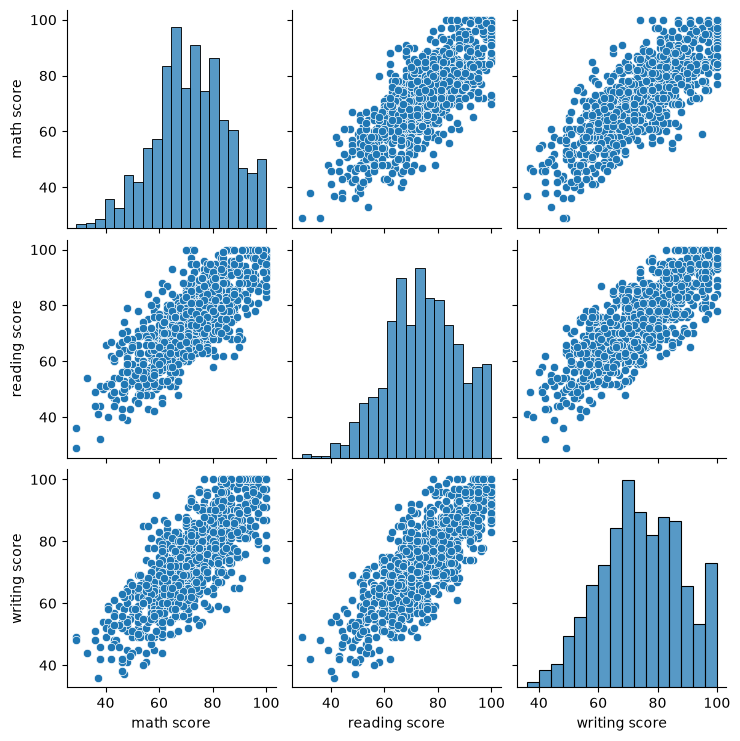

In [40]:
sns.pairplot(clean_data)

<Axes: >

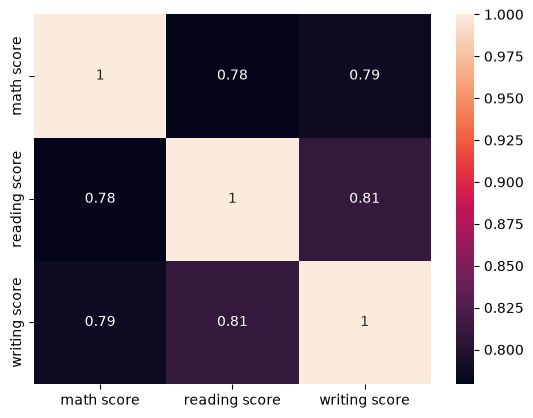

In [39]:
correlation = clean_data.select_dtypes(include='number').corr()
sns.heatmap(correlation,xticklabels=correlation.columns,yticklabels=correlation.columns,annot=True)